In [1]:
import sys
from pathlib import Path
_r = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts' / 'config.py').exists())
sys.path.insert(0, str(_r / 'scripts'))

from notebook_init import setup
cfg, PATHS, POPULATIONS, HARD_FILTERS, SITUATIONAL_FILTERS, ML = setup()

from ml_training import (
    load_ml_data,
    train_random_forest,
    train_xgboost,
    train_logistic_regression,
    evaluate_model,
    cross_validate_model,
    get_feature_importances,
    train_on_top_features,
    save_model,
    run_full_pipeline,
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
try:
    from tabpfn import TabPFNClassifier
    TABPFN_AVAILABLE = True
    print("✓ TabPFN is available")
except ImportError:
    TABPFN_AVAILABLE = False
    print("✗ TabPFN not available (install with: pip install tabpfn)")
TABPFN_AVAILABLE = False
print("\nML Configuration:")
print(f"  Test size: {ML.TEST_SIZE}")
print(f"  Random state: {ML.RANDOM_STATE}")
print(f"  RF estimators: {ML.RF_N_ESTIMATORS}")
print(f"  XGB estimators: {ML.XGB_N_ESTIMATORS}")
print(f"  Top N features: {ML.TOP_N_FEATURES}")
from fileio import ensure_dir
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


Project root : /home/ibmelab/Projects/AISNP_Research
genomes_data : /mnt/data/aisnp_data/1000genomes/
output root  : output
✓ TabPFN is available

ML Configuration:
  Test size: 0.2
  Random state: 42
  RF estimators: 200
  XGB estimators: 200
  Top N features: 25


In [2]:
# Check if all ML results already exist - skip training if so
output_dir = PATHS.ML_MODELS_FST

# Define required output files for this notebook
REQUIRED_OUTPUTS = [
    output_dir / "model_comparison.csv",
    output_dir / "feature_importances.csv",
    output_dir / "feature_size_results.csv",
    output_dir / "fst_only_top50_ml_data.csv",
    output_dir / "random_forest_full.pkl",
]

# Check if all outputs exist
existing_outputs = [f for f in REQUIRED_OUTPUTS if f.exists()]
missing_outputs = [f for f in REQUIRED_OUTPUTS if not f.exists()]

SKIP_TRAINING = len(missing_outputs) == 0

print("="*70)
print("04a FST-ONLY ML TRAINING - OUTPUT CHECK")
print("="*70)

if SKIP_TRAINING:
    print("\n✓ All required outputs already exist!")
    print("  Training will be SKIPPED. Delete outputs to re-run.")
    print(f"\nExisting outputs ({len(existing_outputs)}):")
    for f in existing_outputs:
        print(f"  ✓ {f.name}")
else:
    print(f"\n✗ Missing outputs ({len(missing_outputs)}):")
    for f in missing_outputs:
        print(f"  ✗ {f.name}")
    print("\n→ Training will proceed.")
    if existing_outputs:
        print(f"\nExisting outputs ({len(existing_outputs)}):")
        for f in existing_outputs:
            print(f"  ✓ {f.name}")

04a FST-ONLY ML TRAINING - OUTPUT CHECK

✗ Missing outputs (5):
  ✗ model_comparison.csv
  ✗ feature_importances.csv
  ✗ feature_size_results.csv
  ✗ fst_only_top50_ml_data.csv
  ✗ random_forest_full.pkl

→ Training will proceed.


## Step 1: Prepare ML Data

Check if ML data exists. If not, run VCF conversion pipeline to create it.

In [3]:
import os, numpy as np

ML_DATA_PATH = str(PATHS.ML_DATA)

if os.path.exists(ML_DATA_PATH):
    print(f'✓ ML data cached: {ML_DATA_PATH}')
else:
    print('Building ML data from genotype matrix...')

    # Load full LD-pruned genotype matrix (from pre-filtering/03)
    data = np.load(str(PATHS.GENOTYPE_MATRIX))
    all_snp_ids = open(str(PATHS.GENOTYPE_MATRIX_COLS)).read().splitlines()
    G = data['G']                                   # (n_samples, n_all_snps) int8
    sample_names = list(data['samples'].astype(str))

    # Load FST-selected SNP IDs
    with open(str(PATHS.TOP_SNPS_FILE)) as fh:
        top_snps = [l.strip() for l in fh if l.strip()]
    print(f'FST top SNPs: {len(top_snps)}')

    # Subset matrix columns to FST SNPs (preserves int8)
    snp_to_idx = {s: i for i, s in enumerate(all_snp_ids)}
    matched = [s for s in top_snps if s in snp_to_idx]
    missed  = len(top_snps) - len(matched)
    print(f'Matched in matrix: {len(matched)}  (unmatched: {missed})')

    G_sub = G[:, [snp_to_idx[s] for s in matched]]   # (n_samples, n_fst_snps) int8

    # Add population labels and save
    samples_meta = pd.read_csv(
        str(PATHS.SAMPLES_CSV), header=None, names=['sample', 'pop', 'super_pop']
    )
    pop_map = dict(zip(samples_meta['sample'], samples_meta['pop']))
    pops = [pop_map.get(s, 'unknown') for s in sample_names]

    ml_df = pd.DataFrame(G_sub, columns=matched)
    ml_df.insert(0, 'pop', pops)
    ml_df.insert(0, 'sample', sample_names)

    os.makedirs(str(PATHS.ML_MODELS_FST), exist_ok=True)
    ml_df.to_csv(ML_DATA_PATH, index=False)
    print(f'Saved: {ML_DATA_PATH}  shape={ml_df.shape}')


✓ ML data cached: /mnt/data/aisnp_data/1000genomes/outputs/fst_only/04b_fst_and_pca/ml_data_with_pop.csv


## Step 1a: VCF to Numeric Conversion (if needed)

This section converts VCF data to a numeric genotype matrix suitable for ML.

**Pipeline:**
1. Extract selected SNPs from VCF using BED coordinates
2. Filter to biallelic SNPs only
3. Convert genotypes to numeric (0/1/2)
4. Transpose so samples are rows
5. Add population labels

## Step 1b: Load ML Data

Load the prepared numeric matrix with population labels.

In [4]:
# Load ML data (needed even if skipping training for summary)
X, y, feature_names = load_ml_data(
    ML_DATA_PATH,
    target_column="pop",
    verbose=True,
)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target distribution:")
print(y.value_counts())

# Encode labels (needed for loading saved results)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Classes: {le.classes_}")

Loading data from: /mnt/data/aisnp_data/1000genomes/outputs/fst_only/04b_fst_and_pca/ml_data_with_pop.csv
  Samples: 504
  Features: 2508
  Classes: 3 ({'CN': 208, 'SEA': 192, 'JPT': 104})

Feature matrix shape: (504, 2508)
Target distribution:
pop
CN     208
SEA    192
JPT    104
Name: count, dtype: int64
Classes: ['CN' 'JPT' 'SEA']


In [5]:
# Split data (needed for training)
if not SKIP_TRAINING:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=ML.TEST_SIZE,
        stratify=y,
        random_state=ML.RANDOM_STATE,
    )

    y_train_encoded = le.transform(y_train)
    y_test_encoded = le.transform(y_test)

    print(f"Train set: {len(X_train)} samples")
    print(f"Test set: {len(X_test)} samples")
else:
    print("⏭️ Skipping data split - using cached results")

Train set: 403 samples
Test set: 101 samples


## Step 2: Train Random Forest

In [6]:
# Train Random Forest
if not SKIP_TRAINING:
    rf = train_random_forest(
        X_train, y_train,
        n_estimators=ML.RF_N_ESTIMATORS,
        verbose=True,
    )
else:
    print("⏭️ Skipping Random Forest training - using cached results")


Training Random Forest...
  n_estimators: 200
  max_depth: None


  Training complete!


In [7]:
# Evaluate Random Forest
if not SKIP_TRAINING:
    rf_results = evaluate_model(rf, X_test, y_test, "Random Forest", verbose=True)
else:
    print("⏭️ Skipping RF evaluation - using cached results")


Random Forest EVALUATION
Accuracy: 0.9703
F1 (macro): 0.9713
F1 (weighted): 0.9703
MCC: 0.9541
ROC-AUC (OvR macro): 0.9998

Classification Report:
              precision    recall  f1-score   support

          CN       0.98      0.95      0.96        42
         JPT       1.00      0.95      0.98        21
         SEA       0.95      1.00      0.97        38

    accuracy                           0.97       101
   macro avg       0.98      0.97      0.97       101
weighted avg       0.97      0.97      0.97       101



In [8]:
# Cross-validation
if not SKIP_TRAINING:
    from sklearn.ensemble import RandomForestClassifier

    rf_cv = cross_validate_model(
        RandomForestClassifier(n_estimators=ML.RF_N_ESTIMATORS, random_state=ML.RANDOM_STATE),
        X, y,
        cv=ML.CV_FOLDS,
        model_name="Random Forest",
    )
else:
    print("⏭️ Skipping RF cross-validation - using cached results")


Cross-validating Random Forest (5-fold)...
  CV Accuracy:   0.9623 (+/- 0.0406)
  CV F1 (wtd):   0.9616
  CV MCC:        0.9434
  CV ROC-AUC:    0.9995


## Step 3: Train XGBoost

In [9]:
# Train XGBoost
if not SKIP_TRAINING:
    try:
        xgb_clf = train_xgboost(
            X_train, y_train_encoded,
            n_estimators=ML.XGB_N_ESTIMATORS,
            max_depth=ML.XGB_MAX_DEPTH,
            learning_rate=ML.XGB_LEARNING_RATE,
            verbose=True,
        )
        
        # Evaluate
        xgb_results = evaluate_model(xgb_clf, X_test, y_test_encoded, "XGBoost", verbose=True)
    except ImportError as e:
        print(f"XGBoost not available: {e}")
        xgb_clf = None
else:
    xgb_clf = None
    print("⏭️ Skipping XGBoost training - using cached results")


Training XGBoost...
  n_estimators: 200
  max_depth: 6
  learning_rate: 0.1
  Training complete!

XGBoost EVALUATION
Accuracy: 0.9901
F1 (macro): 0.9917
F1 (weighted): 0.9901
MCC: 0.9847
ROC-AUC (OvR macro): 0.9992

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        42
           1       1.00      1.00      1.00        21
           2       0.97      1.00      0.99        38

    accuracy                           0.99       101
   macro avg       0.99      0.99      0.99       101
weighted avg       0.99      0.99      0.99       101



## Step 4: Train Logistic Regression

In [10]:
# Train Logistic Regression
if not SKIP_TRAINING:
    lr = train_logistic_regression(
        X_train, y_train,
        max_iter=ML.LR_MAX_ITER,
        verbose=True,
    )

    # Evaluate
    lr_results = evaluate_model(lr, X_test, y_test, "Logistic Regression", verbose=True)
else:
    print("⏭️ Skipping Logistic Regression training - using cached results")


Training Logistic Regression...
  max_iter: 1000
  solver: lbfgs


  Training complete!

Logistic Regression EVALUATION
Accuracy: 1.0000
F1 (macro): 1.0000
F1 (weighted): 1.0000
MCC: 1.0000
ROC-AUC (OvR macro): 1.0000

Classification Report:
              precision    recall  f1-score   support

          CN       1.00      1.00      1.00        42
         JPT       1.00      1.00      1.00        21
         SEA       1.00      1.00      1.00        38

    accuracy                           1.00       101
   macro avg       1.00      1.00      1.00       101
weighted avg       1.00      1.00      1.00       101



## Step 5: Compare Models

In [11]:
# Collect results or load from cache
if not SKIP_TRAINING:
    results = {
        "Random Forest": rf_results,
        "Logistic Regression": lr_results,
    }
    if xgb_clf is not None:
        results["XGBoost"] = xgb_results

    # Comparison table
    comparison_df = pd.DataFrame({
        "Model": results.keys(),
        "Accuracy": [r["accuracy"] for r in results.values()],
        "F1 (macro)": [r["f1_macro"] for r in results.values()],
        "F1 (weighted)": [r["f1_weighted"] for r in results.values()],
    })

    print("Model Comparison:")
    display(comparison_df)
else:
    # Load cached results
    comparison_df = pd.read_csv(output_dir / "model_comparison.csv")
    print("📊 Loaded cached model comparison:")
    display(comparison_df)

Model Comparison:


,Model,Accuracy,F1 (macro),F1 (weighted)
0,Random Forest,0.970297,0.971275,0.970251
1,Logistic Regression,1.000000,1.000000,1.000000
2,XGBoost,0.990099,0.991655,0.990104


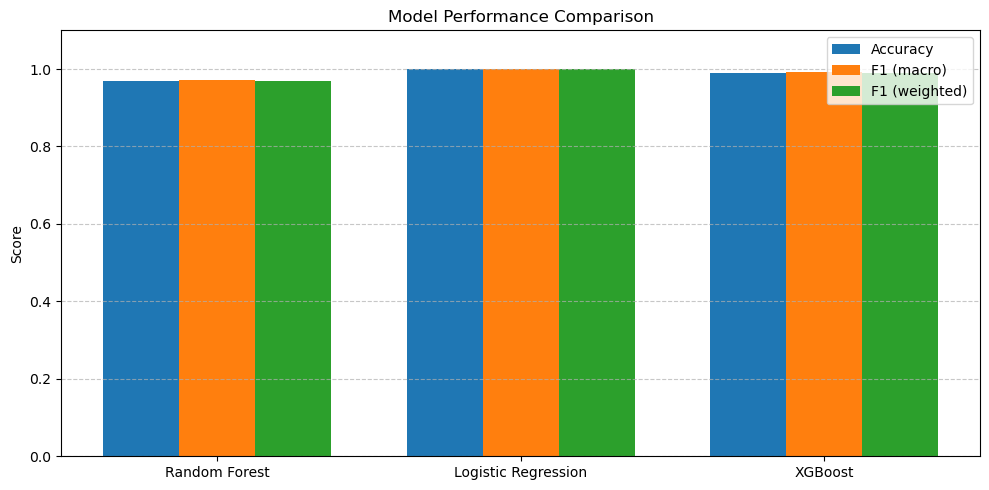

In [12]:
# Visualize comparison
if not SKIP_TRAINING:
    fig, ax = plt.subplots(figsize=(10, 5))

    x = np.arange(len(comparison_df))
    width = 0.25

    ax.bar(x - width, comparison_df["Accuracy"], width, label="Accuracy")
    ax.bar(x, comparison_df["F1 (macro)"], width, label="F1 (macro)")
    ax.bar(x + width, comparison_df["F1 (weighted)"], width, label="F1 (weighted)")

    ax.set_ylabel("Score")
    ax.set_title("Model Performance Comparison")
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_df["Model"])
    ax.legend()
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
else:
    print("⏭️ Skipping visualization - using cached results")

## Step 6: Confusion Matrices

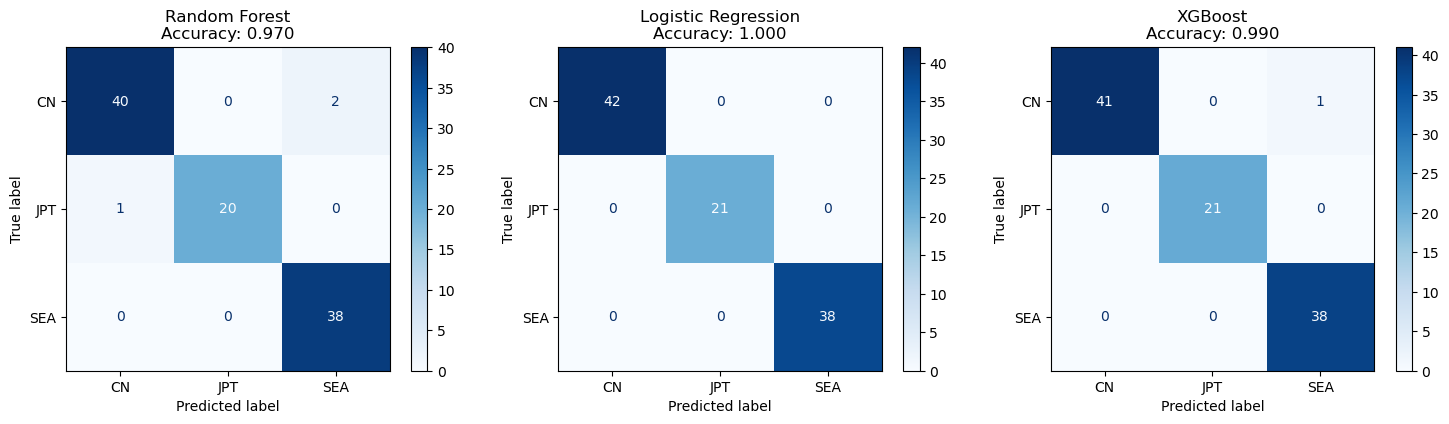

In [13]:
# Plot confusion matrices
if not SKIP_TRAINING:
    fig, axes = plt.subplots(1, len(results), figsize=(5*len(results), 4))

    if len(results) == 1:
        axes = [axes]

    for ax, (name, result) in zip(axes, results.items()):
        ConfusionMatrixDisplay(
            result["confusion_matrix"],
            display_labels=le.classes_,
        ).plot(ax=ax, cmap="Blues")
        ax.set_title(f"{name}\nAccuracy: {result['accuracy']:.3f}")

    plt.tight_layout()
    plt.show()
else:
    print("⏭️ Skipping confusion matrix plots - using cached results")

In [14]:
# Get feature importances from Random Forest (or load from cache)
if not SKIP_TRAINING:
    rf_importance = get_feature_importances(
        rf, feature_names,
        top_n=ML.TOP_N_FEATURES,
        verbose=True,
    )
else:
    rf_importance = pd.read_csv(output_dir / "feature_importances.csv")
    print(f"📊 Loaded cached feature importances: {len(rf_importance)} features")


Top 25 Features by Importance:
  4:17813761_b37_G,A: 0.011083
  3:152553769_b37_C,T: 0.010410
  9:37486004_b37_C,G: 0.010368
  1:12387655_b37_G,A: 0.010285
  5:41181491_b37_G,T: 0.009708
  3:86028382_b37_G,T: 0.008853
  1:22315762_b37_C,A: 0.008602
  19:54792079_b37_G,T: 0.008122
  6:152588967_b37_C,G: 0.006877
  11:112053732_b37_T,A: 0.006173
  21:38533017_b37_G,A: 0.006047
  9:98231346_b37_C,G: 0.005154
  16:33974960_b37_G,A: 0.004939
  9:133578385_b37_T,G: 0.004781
  10:134188783_b37_A,G: 0.004623
  9:117013044_b37_A,C: 0.004338
  6:82912256_b37_T,A: 0.004128
  1:102457870_b37_G,A: 0.004072
  20:33681323_b37_T,C: 0.003970
  1:33070778_b37_G,A: 0.003624
  10:7500776_b37_G,A: 0.003561
  1:173157764_b37_G,A: 0.003539
  12:4388084_b37_C,G: 0.003292
  17:7924746_b37_C,T: 0.003279
  5:142757506_b37_G,A: 0.003262


## Step 8b: Test Multiple Feature Set Sizes (5 to 50 SNPs)

Evaluate model performance across different numbers of top SNPs to find the optimal feature set size.

In [15]:
# Define feature set sizes to test (5 to 50, increment of 5)
if not SKIP_TRAINING:
    feature_sizes = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

    # ── Reductor: Logistic Regression |coefficient| over the full FST feature set ──
    # Single CONTROLLED, interpretable reduction method used across ALL pipeline
    # approaches (FST, V2 stat, V2 FST+stat). RF importance
    # is kept in feature_importances.csv for reference only.
    # See 07_reduction_methods.ipynb for the leak-free robustness check.
    _scaler_imp = StandardScaler()
    _X_full_sc = _scaler_imp.fit_transform(X)
    _lr_imp = LogisticRegression(max_iter=ML.LR_MAX_ITER, random_state=ML.RANDOM_STATE,
                                 multi_class='multinomial', n_jobs=-1)
    _lr_imp.fit(_X_full_sc, y)
    lr_importance = pd.DataFrame({
        'feature': feature_names,
        'lr_importance': np.abs(_lr_imp.coef_).mean(axis=0),
    }).sort_values('lr_importance', ascending=False).reset_index(drop=True)
    lr_importance.to_csv(output_dir / "lr_feature_importances.csv", index=False)

    # Ordered list of top features by LR coefficient (the chosen reductor)
    top_features_ordered = lr_importance['feature'].tolist()

    # Limit to available features
    max_features = min(50, len(top_features_ordered))
    feature_sizes = [s for s in feature_sizes if s <= max_features]

    print(f"Reductor: LR |coefficient|  |  testing feature set sizes: {feature_sizes}")
    print(f"Total available features: {len(top_features_ordered)}")
else:
    print("⏭️ Skipping feature size definition - using cached results")

Reductor: LR |coefficient|  |  testing feature set sizes: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
Total available features: 2508


In [16]:
# Test each feature set size with multiple classifiers
if not SKIP_TRAINING:
    from sklearn.model_selection import StratifiedKFold, cross_validate as _cv
    from sklearn.preprocessing import StandardScaler

    # Select classifiers to test
    test_classifiers = {
        'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
        'XGBoost': xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, 
                                      random_state=42, n_jobs=-1, verbosity=0),
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, 
                                                   multi_class='multinomial', n_jobs=-1),
        'SVM (RBF)': SVC(kernel='rbf', random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scaler = StandardScaler()
    _scoring = {'accuracy': 'accuracy', 'f1': 'f1_weighted', 'mcc': 'matthews_corrcoef'}

    feature_size_results = []

    for n_features in feature_sizes:
        print(f"\n{'='*60}")
        print(f"Testing with TOP {n_features} SNPs")
        print(f"{'='*60}")
        
        # Get top N features
        top_n_features = top_features_ordered[:n_features]
        X_reduced = X[top_n_features]
        X_reduced_scaled = scaler.fit_transform(X_reduced)
        
        for clf_name, clf in test_classifiers.items():
            # Clone classifier for fresh training
            clf_clone = clf.__class__(**clf.get_params())
            
            # Use scaled data for SVM and LR
            if 'SVM' in clf_name or 'Logistic' in clf_name:
                X_use = X_reduced_scaled
            else:
                X_use = X_reduced.values
            
            # Use encoded labels for XGBoost
            if 'XGBoost' in clf_name:
                y_use = y_encoded
            else:
                y_use = y
            
            try:
                cv_out = _cv(clf_clone, X_use, y_use, cv=cv, scoring=_scoring)
                feature_size_results.append({
                    'N_Features': n_features,
                    'Model': clf_name,
                    'Accuracy_Mean': cv_out['test_accuracy'].mean(),
                    'Accuracy_Std': cv_out['test_accuracy'].std(),
                    'F1_Mean': cv_out['test_f1'].mean(),
                    'F1_Std': cv_out['test_f1'].std(),
                    'MCC_Mean': cv_out['test_mcc'].mean(),
                    'MCC_Std': cv_out['test_mcc'].std(),
                })
                print(f"  {clf_name}: acc={cv_out['test_accuracy'].mean():.4f}  f1={cv_out['test_f1'].mean():.4f}")
            except Exception as e:
                print(f"  {clf_name}: Error - {e}")
                feature_size_results.append({
                    'N_Features': n_features,
                    'Model': clf_name,
                    'Accuracy_Mean': np.nan,
                    'Accuracy_Std': np.nan,
                    'F1_Mean': np.nan,
                    'F1_Std': np.nan,
                    'MCC_Mean': np.nan,
                    'MCC_Std': np.nan,
                })

    feature_size_df = pd.DataFrame(feature_size_results)
    print("\n" + "="*60)
    print("Feature size testing complete!")
else:
    # Load cached feature size results
    feature_size_df = pd.read_csv(output_dir / 'feature_size_results.csv')
    print("⏭️ Loaded cached feature size results")


Testing with TOP 5 SNPs
  Random Forest: acc=0.5337  f1=0.4662
  XGBoost: acc=0.5337  f1=0.4662
  Logistic Regression: acc=0.5337  f1=0.4662
  SVM (RBF): acc=0.5357  f1=0.4682
  Gradient Boosting: acc=0.5337  f1=0.4662

Testing with TOP 10 SNPs
  Random Forest: acc=0.6110  f1=0.6135
  XGBoost: acc=0.6229  f1=0.6246
  Logistic Regression: acc=0.6428  f1=0.6398
  SVM (RBF): acc=0.6428  f1=0.6389
  Gradient Boosting: acc=0.6010  f1=0.6034

Testing with TOP 15 SNPs
  Random Forest: acc=0.6507  f1=0.6440
  XGBoost: acc=0.6467  f1=0.6444
  Logistic Regression: acc=0.6904  f1=0.6903
  SVM (RBF): acc=0.6725  f1=0.6691
  Gradient Boosting: acc=0.6209  f1=0.6167

Testing with TOP 20 SNPs
  Random Forest: acc=0.6885  f1=0.6812
  XGBoost: acc=0.7004  f1=0.6981
  Logistic Regression: acc=0.7303  f1=0.7283
  SVM (RBF): acc=0.7183  f1=0.7106
  Gradient Boosting: acc=0.6527  f1=0.6479

Testing with TOP 25 SNPs
  Random Forest: acc=0.7242  f1=0.7182
  XGBoost: acc=0.6924  f1=0.6909
  Logistic Regressi

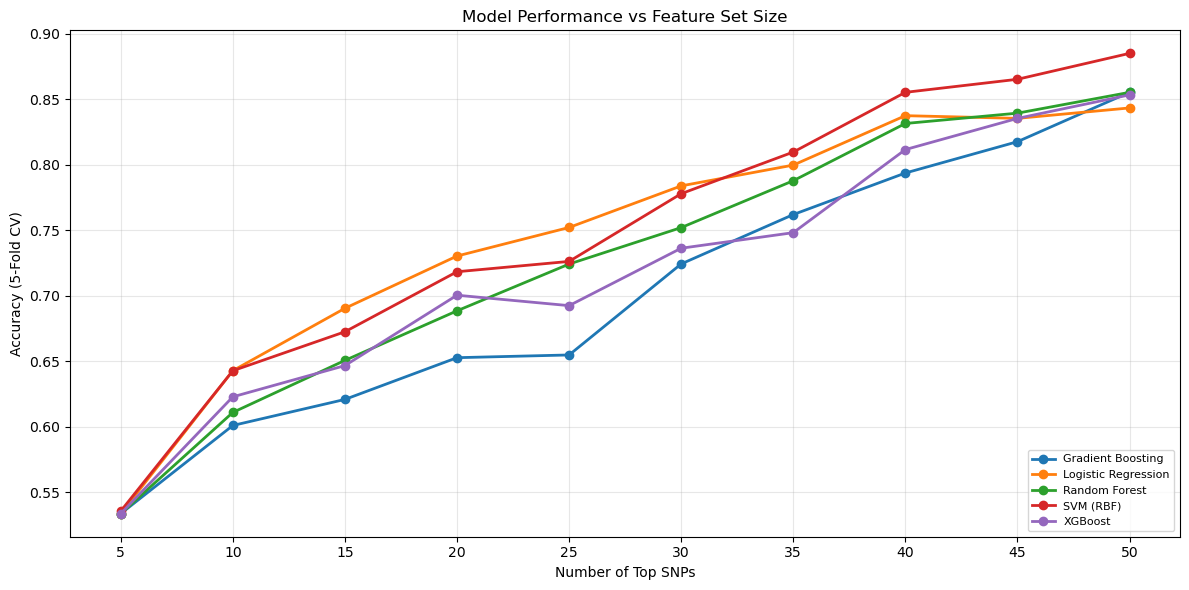

In [17]:
# Derive feature_sizes from the DataFrame (works whether training just ran or was loaded from cache)
feature_sizes = sorted(feature_size_df['N_Features'].unique().tolist())

# Pivot table for visualization
pivot_df = feature_size_df.pivot(index='Model', columns='N_Features', values='Accuracy_Mean')

# Plot 1: Line plot - Accuracy vs Feature Size by Model
fig, ax = plt.subplots(figsize=(12, 6))
for model in pivot_df.index:
    ax.plot(feature_sizes, pivot_df.loc[model].values, 'o-', label=model, linewidth=2, markersize=6)
ax.set_xlabel('Number of Top SNPs')
ax.set_ylabel('Accuracy (5-Fold CV)')
ax.set_title('Model Performance vs Feature Set Size')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xticks(feature_sizes)
plt.tight_layout()
plt.savefig(str(output_dir / 'feature_size_line_plot.png'), dpi=150, bbox_inches='tight')
plt.show()

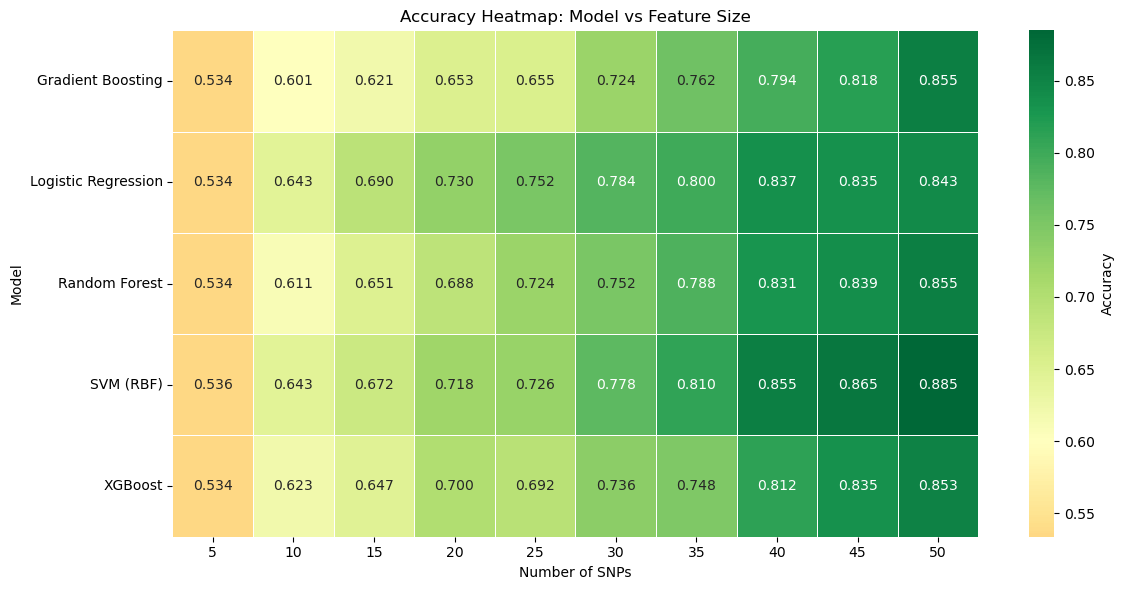

In [18]:
# Plot 2: Heatmap - Accuracy by Model and Feature Size
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_df, annot=True, fmt='.3f', cmap='RdYlGn', center=0.6,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Accuracy'})
ax.set_title('Accuracy Heatmap: Model vs Feature Size')
ax.set_xlabel('Number of SNPs')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig(str(output_dir / 'feature_size_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

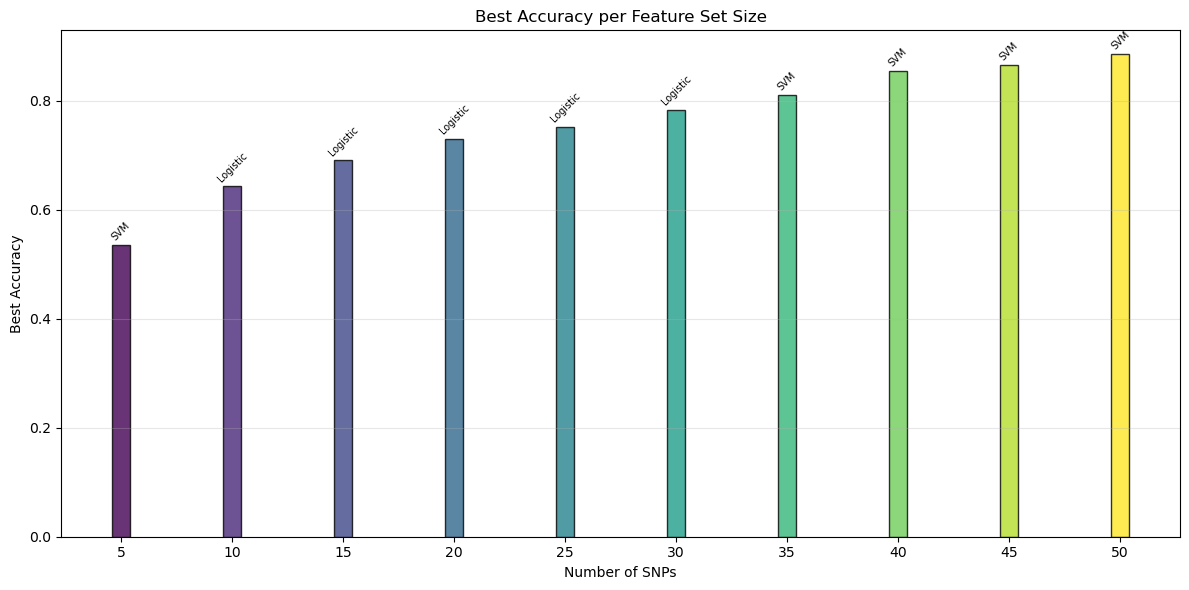


Best Model per Feature Size:
   5 SNPs: SVM (RBF)            (0.5357 ± 0.0218)
  10 SNPs: Logistic Regression  (0.6428 ± 0.0405)
  15 SNPs: Logistic Regression  (0.6904 ± 0.0484)
  20 SNPs: Logistic Regression  (0.7303 ± 0.0326)
  25 SNPs: Logistic Regression  (0.7521 ± 0.0313)
  30 SNPs: Logistic Regression  (0.7838 ± 0.0248)
  35 SNPs: SVM (RBF)            (0.8096 ± 0.0264)
  40 SNPs: SVM (RBF)            (0.8552 ± 0.0255)
  45 SNPs: SVM (RBF)            (0.8651 ± 0.0261)
  50 SNPs: SVM (RBF)            (0.8849 ± 0.0081)

Results saved to: /mnt/data/aisnp_data/1000genomes/outputs/fst/05b_fst_only_training/feature_size_results.csv


In [19]:
# Plot 3: Best model per feature size
best_per_size = feature_size_df.loc[feature_size_df.groupby('N_Features')['Accuracy_Mean'].idxmax()]

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(best_per_size)))
bars = ax.bar(best_per_size['N_Features'], best_per_size['Accuracy_Mean'], 
              color=colors, edgecolor='black', alpha=0.8)
ax.set_xlabel('Number of SNPs')
ax.set_ylabel('Best Accuracy')
ax.set_title('Best Accuracy per Feature Set Size')
ax.set_xticks(feature_sizes)
ax.grid(True, alpha=0.3, axis='y')

# Add model names on bars
for bar, model in zip(bars, best_per_size['Model']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            model.split()[0], ha='center', va='bottom', fontsize=7, rotation=45)

plt.tight_layout()
plt.savefig(str(output_dir / 'feature_size_best_model.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print("\nBest Model per Feature Size:")
print("="*60)
for _, row in best_per_size.iterrows():
    print(f"  {int(row['N_Features']):2d} SNPs: {row['Model']:<20} ({row['Accuracy_Mean']:.4f} ± {row['Accuracy_Std']:.4f})")

# Save results
feature_size_df.to_csv(str(output_dir / 'feature_size_results.csv'), index=False)
pivot_df.to_csv(str(output_dir / 'feature_size_pivot.csv'))
print(f"\nResults saved to: {output_dir / 'feature_size_results.csv'}")

## Step 8c: TabPFN Evaluation on 25-50 Top SNPs

TabPFN is a transformer-based model optimized for small tabular datasets. Test it across feature sizes from 25 to 50 SNPs.

In [20]:
# TabPFN evaluation on 25-50 SNPs
if not SKIP_TRAINING and TABPFN_AVAILABLE:
    from tabpfn import TabPFNClassifier
    
    # Feature sizes for TabPFN (25 to 50)
    tabpfn_feature_sizes = [25, 30, 35, 40, 45, 50]
    tabpfn_feature_sizes = [s for s in tabpfn_feature_sizes if s <= max_features]
    
    tabpfn_results_list = []
    
    print("Testing TabPFN across feature sizes (25-50 SNPs)...")
    print("="*60)
    
    for n_features in tabpfn_feature_sizes:
        print(f"\n>>> TabPFN with {n_features} SNPs...")
        
        # Get top N features
        top_n_features = top_features_ordered[:n_features]
        X_reduced = X[top_n_features]
        
        # 5-Fold CV for TabPFN
        cv_scores_tabpfn = []
        
        for train_idx, val_idx in cv.split(X_reduced, y):
            try:
                tabpfn_cv = TabPFNClassifier(device='cpu', n_estimators=4)
                X_train_cv = X_reduced.values[train_idx]
                y_train_cv = y_encoded[train_idx]
                X_val_cv = X_reduced.values[val_idx]
                y_val_cv = y_encoded[val_idx]
                
                tabpfn_cv.fit(X_train_cv, y_train_cv)
                y_pred_cv = tabpfn_cv.predict(X_val_cv)
                
                from sklearn.metrics import accuracy_score
                cv_scores_tabpfn.append(accuracy_score(y_val_cv, y_pred_cv))
            except Exception as e:
                print(f"    Fold error: {e}")
                cv_scores_tabpfn.append(np.nan)
        
        mean_acc = np.nanmean(cv_scores_tabpfn)
        std_acc = np.nanstd(cv_scores_tabpfn)
        
        tabpfn_results_list.append({
            'N_Features': n_features,
            'Model': 'TabPFN',
            'Accuracy_Mean': mean_acc,
            'Accuracy_Std': std_acc
        })
        
        print(f"    Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
    
    tabpfn_df = pd.DataFrame(tabpfn_results_list)
    print("\n" + "="*60)
    print("TabPFN testing complete!")
elif SKIP_TRAINING:
    # Load cached TabPFN results if available
    tabpfn_csv_path = output_dir / 'tabpfn_feature_size_results.csv'
    if tabpfn_csv_path.exists():
        tabpfn_df = pd.read_csv(tabpfn_csv_path)
        print("⏭️ Loaded cached TabPFN feature size results")
    else:
        tabpfn_df = pd.DataFrame()
        print("⏭️ Skipping TabPFN evaluation - no cached results available")
else:
    print("TabPFN not available. Install with: pip install tabpfn")
    tabpfn_df = pd.DataFrame()

TabPFN not available. Install with: pip install tabpfn


In [21]:
# Visualize TabPFN results and compare with other models
if not SKIP_TRAINING and TABPFN_AVAILABLE and len(tabpfn_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: TabPFN accuracy vs feature size
    ax = axes[0]
    ax.errorbar(tabpfn_df['N_Features'], tabpfn_df['Accuracy_Mean'], 
                yerr=tabpfn_df['Accuracy_Std'], fmt='o-', linewidth=2, 
                markersize=8, capsize=5, color='purple', label='TabPFN')
    ax.set_xlabel('Number of Top SNPs')
    ax.set_ylabel('Accuracy (5-Fold CV)')
    ax.set_title('TabPFN Performance vs Feature Set Size (25-50 SNPs)')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(tabpfn_feature_sizes)
    ax.legend()
    
    # Plot 2: Compare TabPFN with best other model at each size
    ax = axes[1]
    
    # Get best non-TabPFN model for sizes 25-50
    comparison_sizes = [s for s in tabpfn_feature_sizes if s in feature_sizes]
    best_other = feature_size_df[feature_size_df['N_Features'].isin(comparison_sizes)]
    best_other = best_other.loc[best_other.groupby('N_Features')['Accuracy_Mean'].idxmax()]
    
    x = np.arange(len(comparison_sizes))
    width = 0.35
    
    tabpfn_acc = tabpfn_df[tabpfn_df['N_Features'].isin(comparison_sizes)]['Accuracy_Mean'].values
    other_acc = best_other['Accuracy_Mean'].values
    other_models = best_other['Model'].values
    
    bars1 = ax.bar(x - width/2, tabpfn_acc, width, label='TabPFN', color='purple', alpha=0.8)
    bars2 = ax.bar(x + width/2, other_acc, width, label='Best Other Model', color='steelblue', alpha=0.8)
    
    ax.set_xlabel('Number of SNPs')
    ax.set_ylabel('Accuracy')
    ax.set_title('TabPFN vs Best Other Model (25-50 SNPs)')
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_sizes)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add model names on bars
    for bar, model in zip(bars2, other_models):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                model.split()[0], ha='center', va='bottom', fontsize=7, rotation=45)
    
    plt.tight_layout()
    plt.savefig(str(output_dir / 'tabpfn_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print comparison summary
    print("\nTabPFN vs Best Other Model (25-50 SNPs):")
    print("="*70)
    print(f"{'N_SNPs':<10} {'TabPFN':<15} {'Best Other':<15} {'Model':<20}")
    print("-"*70)
    for i, n in enumerate(comparison_sizes):
        print(f"{n:<10} {tabpfn_acc[i]:<15.4f} {other_acc[i]:<15.4f} {other_models[i]:<20}")
    
    # Save TabPFN results
    tabpfn_df.to_csv(str(output_dir / 'tabpfn_feature_size_results.csv'), index=False)
    print(f"\nTabPFN results saved to: {output_dir / 'tabpfn_feature_size_results.csv'}")
else:
    print("⏭️ Skipping TabPFN visualization - using cached results or TabPFN not available")

⏭️ Skipping TabPFN visualization - using cached results or TabPFN not available


## Step 9: Save Models

In [22]:
# Create output directory and save models
if not SKIP_TRAINING:
    output_dir = ensure_dir(PATHS.ML_MODELS_FST)

    # Save full feature models
    save_model(
        rf, output_dir / "random_forest_full.pkl",
        metadata={"n_features": len(feature_names), "accuracy": rf_results["accuracy"]},
    )

    save_model(
        lr, output_dir / "logistic_regression_full.pkl",
        metadata={"accuracy": lr_results["accuracy"]},
    )

    if xgb_clf is not None:
        save_model(
            xgb_clf, output_dir / "xgboost_full.pkl",
            metadata={"accuracy": xgb_results["accuracy"]},
        )

    # Save feature importance
    rf_importance.to_csv(output_dir / "feature_importances.csv", index=False)

    # Save top features list
    top_feature_df = rf_importance.head(ML.TOP_N_FEATURES)
    top_feature_df.to_csv(output_dir / f"top_{ML.TOP_N_FEATURES}_features.csv", index=False)

    # Save model comparison — best result per model across all feature sizes, including F1
    best_per_model = feature_size_df.loc[feature_size_df.groupby('Model')['Accuracy_Mean'].idxmax()]
    f1_cols = ['F1_Mean', 'F1_Std'] if 'F1_Mean' in feature_size_df.columns else []
    mcc_cols = ['MCC_Mean', 'MCC_Std'] if 'MCC_Mean' in feature_size_df.columns else []
    keep_cols = ['Model', 'Accuracy_Mean', 'Accuracy_Std'] + f1_cols + mcc_cols + ['N_Features']
    comparison_results = best_per_model[keep_cols].copy()
    rename_map = {'Model': 'model', 'Accuracy_Mean': 'accuracy', 'Accuracy_Std': 'accuracy_std',
                  'N_Features': 'best_n_features'}
    if f1_cols:
        rename_map.update({'F1_Mean': 'f1_mean', 'F1_Std': 'f1_std'})
    if mcc_cols:
        rename_map.update({'MCC_Mean': 'mcc_mean', 'MCC_Std': 'mcc_std'})
    comparison_results = comparison_results.rename(columns=rename_map)
    comparison_results = comparison_results.sort_values('accuracy', ascending=False)
    comparison_results.to_csv(output_dir / "model_comparison.csv", index=False)

    # Save full feature size sweep results (includes F1)
    feature_size_df.to_csv(output_dir / "feature_size_results.csv", index=False)

    # Save TabPFN results if available
    if TABPFN_AVAILABLE and len(tabpfn_df) > 0:
        tabpfn_df.to_csv(output_dir / "tabpfn_feature_size_results.csv", index=False)

    print(f"\nAll models saved to: {output_dir}")
    print(f"  - model_comparison.csv  (accuracy + f1 per model)")
    print(f"  - feature_size_results.csv")
    print(f"  - feature_importances.csv")
else:
    print("⏭️ Skipping model saving - using cached results")

Model saved to: /mnt/data/aisnp_data/1000genomes/outputs/fst/05b_fst_only_training/random_forest_full.pkl
Model saved to: /mnt/data/aisnp_data/1000genomes/outputs/fst/05b_fst_only_training/logistic_regression_full.pkl
Model saved to: /mnt/data/aisnp_data/1000genomes/outputs/fst/05b_fst_only_training/xgboost_full.pkl

All models saved to: /mnt/data/aisnp_data/1000genomes/outputs/fst/05b_fst_only_training
  - model_comparison.csv  (accuracy + f1 per model)
  - feature_size_results.csv
  - feature_importances.csv


In [23]:
# Save Top 50 FST-only SNPs ML Data Matrix for Part 2 comparison
if not SKIP_TRAINING:
    TOP_50 = 50

    # Get top 50 SNP names from the LR reductor ranking (consistent with the sweep)
    top_50_snps = lr_importance.head(TOP_50)['feature'].tolist()

    # Create ML data matrix with only top 50 SNPs
    # Load original ML data to get sample info
    import pandas as pd
    ml_data_full = pd.read_csv(ML_DATA_PATH)
    sample_ids = ml_data_full['sample']
    populations = ml_data_full['pop']

    # Get top 50 SNP columns
    top_50_snp_cols = [c for c in top_50_snps if c in ml_data_full.columns]
    print(f"Top 50 SNPs available in ML data: {len(top_50_snp_cols)}")

    # Create the top 50 ML data matrix
    fst_top50_df = ml_data_full[['sample', 'pop'] + top_50_snp_cols].copy()

    # Save to output directory
    fst_top50_path = output_dir / "fst_only_top50_ml_data.csv"
    fst_top50_df.to_csv(fst_top50_path, index=False)
    print(f"\nFST-only Top 50 ML data saved to: {fst_top50_path}")
    print(f"  Samples: {len(fst_top50_df)}")
    print(f"  SNPs: {len(top_50_snp_cols)}")

    # Also save top 50 SNP IDs for reference
    top50_ids_path = output_dir / "fst_only_top50_snp_ids.txt"
    with open(top50_ids_path, 'w') as f:
        for snp in top_50_snp_cols:
            f.write(f"{snp}\n")
    print(f"Top 50 SNP IDs saved to: {top50_ids_path}")

    # Save top 50 feature importance (LR)
    top50_importance_path = output_dir / "fst_only_top50_features.csv"
    lr_importance.head(TOP_50).to_csv(top50_importance_path, index=False)
    print(f"Top 50 feature importance saved to: {top50_importance_path}")
else:
    print("⏭️ Skipping Top 50 ML data saving - using cached results")

Top 50 SNPs available in ML data: 0

FST-only Top 50 ML data saved to: /mnt/data/aisnp_data/1000genomes/outputs/fst/05b_fst_only_training/fst_only_top50_ml_data.csv
  Samples: 504
  SNPs: 0
Top 50 SNP IDs saved to: /mnt/data/aisnp_data/1000genomes/outputs/fst/05b_fst_only_training/fst_only_top50_snp_ids.txt
Top 50 feature importance saved to: /mnt/data/aisnp_data/1000genomes/outputs/fst/05b_fst_only_training/fst_only_top50_features.csv


## Summary

In [24]:
# Summary of training results
print("="*70)
print("ML TRAINING SUMMARY")
print("="*70)
if SKIP_TRAINING:
    print("\n⏭️ SKIP_TRAINING MODE: Using cached results")

print(f"\nData:")
print(f"  Total Samples: {len(X)}")
print(f"  Total Features: {len(feature_names)}")
print(f"  Classes: {len(le.classes_)} ({list(le.classes_)})")

# Find best model from feature size testing
best_per_model = feature_size_df.loc[feature_size_df.groupby('Model')['Accuracy_Mean'].idxmax()]
best_per_model_sorted = best_per_model.sort_values('Accuracy_Mean', ascending=False)
best_overall = best_per_model_sorted.iloc[0]

print(f"\n🏆 Best Model: {best_overall['Model']}")
print(f"   Best N_Features: {int(best_overall['N_Features'])}")
print(f"   Accuracy: {best_overall['Accuracy_Mean']:.4f} ± {best_overall['Accuracy_Std']:.4f}")

print(f"\nModel Rankings (best feature size per model):")
print("-"*70)
for rank, (_, row) in enumerate(best_per_model_sorted.iterrows(), 1):
    print(f"  {rank}. {row['Model']:<25} {row['Accuracy_Mean']:.4f} (at {int(row['N_Features'])} SNPs)")

print(f"\nOutput directory: {output_dir}")
print(f"\nNext step: Run 05_model_evaluation.ipynb for detailed analysis")

ML TRAINING SUMMARY

Data:
  Total Samples: 504
  Total Features: 2508
  Classes: 3 (['CN', 'JPT', 'SEA'])

🏆 Best Model: SVM (RBF)
   Best N_Features: 50
   Accuracy: 0.8849 ± 0.0081

Model Rankings (best feature size per model):
----------------------------------------------------------------------
  1. SVM (RBF)                 0.8849 (at 50 SNPs)
  2. Gradient Boosting         0.8552 (at 50 SNPs)
  3. Random Forest             0.8552 (at 50 SNPs)
  4. XGBoost                   0.8532 (at 50 SNPs)
  5. Logistic Regression       0.8433 (at 50 SNPs)

Output directory: /mnt/data/aisnp_data/1000genomes/outputs/fst/05b_fst_only_training

Next step: Run 05_model_evaluation.ipynb for detailed analysis


## Step 10: Dual-Reductor Fine-Grid Sweep (for cross-path comparison in 06)

Runs the panel sweep with **both RF and LR rankings** over a fine grid
`[5..80 step 5, 90, 100]`, recording acc / F1 / MCC / ROC-AUC for 6 classifiers.
Saves `reductor_sweep.csv` (column `reductor` = RF/LR). Always runs (not gated by
SKIP_TRAINING) since it only needs the loaded `X`, `y`.

In [25]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

FINE_GRID = [n for n in [5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,90,100]
             if n <= X.shape[1]]

# Build RF and LR rankings on full data (global; same leakage level across all paths)
Xv = X.values
_rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1).fit(Xv, y)
rf_order = [feature_names[i] for i in np.argsort(_rf.feature_importances_)[::-1]]
_lr = LogisticRegression(max_iter=ML.LR_MAX_ITER, random_state=42, multi_class='multinomial',
                         n_jobs=-1).fit(StandardScaler().fit_transform(Xv), y)
lr_order = [feature_names[i] for i in np.argsort(np.abs(_lr.coef_).mean(axis=0))[::-1]]

red_clfs = {
    'Random Forest':     RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost':           xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                                           random_state=42, n_jobs=-1, verbosity=0),
    'Logistic Reg':      LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial', n_jobs=-1),
    'SVM (RBF)':         SVC(kernel='rbf',    random_state=42, probability=True),
    'SVM (Linear)':      SVC(kernel='linear', random_state=42, probability=True),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
}
RNS = {'Logistic Reg', 'SVM (RBF)', 'SVM (Linear)'}
RNE = {'XGBoost'}
rcv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rsc = {'accuracy': 'accuracy', 'f1': 'f1_weighted', 'mcc': 'matthews_corrcoef', 'roc_auc': 'roc_auc_ovr'}

rows = []
for red, order in [('RF', rf_order), ('LR', lr_order)]:
    for n in FINE_GRID:
        cols = order[:n]
        Xp  = X[cols].values
        Xps = StandardScaler().fit_transform(Xp)
        for cn, clf in red_clfs.items():
            Xu = Xps if cn in RNS else Xp
            yu = y_encoded if cn in RNE else y
            try:
                o = cross_validate(clf.__class__(**clf.get_params()), Xu, yu, cv=rcv, scoring=rsc)
                rows.append({'reductor': red, 'n_snps': n, 'classifier': cn,
                             'acc_mean': o['test_accuracy'].mean(), 'acc_std': o['test_accuracy'].std(),
                             'f1_mean': o['test_f1'].mean(), 'mcc_mean': o['test_mcc'].mean(),
                             'roc_auc_mean': o['test_roc_auc'].mean()})
            except Exception as e:
                rows.append({'reductor': red, 'n_snps': n, 'classifier': cn,
                             'acc_mean': np.nan, 'acc_std': np.nan, 'f1_mean': np.nan,
                             'mcc_mean': np.nan, 'roc_auc_mean': np.nan})
    print(f'{red}: done {len(FINE_GRID)} panel sizes')

reductor_sweep_df = pd.DataFrame(rows)
reductor_sweep_df.to_csv(output_dir / 'reductor_sweep.csv', index=False)
print('Saved', output_dir / 'reductor_sweep.csv', reductor_sweep_df.shape)
# Quick peek: best per reductor at 50 SNPs
for red in ('RF', 'LR'):
    s = reductor_sweep_df[(reductor_sweep_df.reductor == red) & (reductor_sweep_df.n_snps == 50)]
    if not s.empty:
        b = s.loc[s.acc_mean.idxmax()]
        print(f'  {red} @50: {b.classifier} acc={b.acc_mean:.4f} mcc={b.mcc_mean:.4f}')

RF: done 18 panel sizes
LR: done 18 panel sizes
Saved /mnt/data/aisnp_data/1000genomes/outputs/fst/05b_fst_only_training/reductor_sweep.csv (216, 8)
  RF @50: SVM (RBF) acc=0.9405 mcc=0.9086
  LR @50: SVM (RBF) acc=0.8849 mcc=0.8220
